# CP1 — AI & Deep Learning: CNN do dado ao deploy
## Desafio final — Caminho C (Serviço completo)

Grupo: Bruno Tomin (RM565037) e Cynthia Takematu (RM564100)

Repositório: https://github.com/cynthiatakematu/fiap-cp01-ai-deep-learning



Este notebook executa o pipeline completo da disciplina (etapas 1–7) e implementa as
extensões do **Caminho C** sobre a API de inferência:

1. `POST /prever_lote` — classificação de várias imagens em uma única requisição (um único *forward* em lote);
2. Registro em arquivo (`logs/baixa_confianca.jsonl`) de toda predição com confiança < 0,5;
3. `GET /metricas` — contagem de requisições, total de predições e latência média;
4. Imagem Docker funcional (comandos ao final — o *build* é feito localmente, pois o Colab não executa Docker).


## 1. Preparação do ambiente

Clona o repositório da disciplina e instala as dependências. A semente fixa usada
pelos scripts (`definir_semente(42)`) garante a reprodutibilidade dos resultados.

In [ ]:
# Clona o repositório do GitHub
!git clone https://github.com/carvalhoamc/fiap.git

# Entra no diretório da atividade de CNN
%cd fiap/2tsCPV-2/cnn

Cloning into 'fiap'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 87 (delta 18), reused 76 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 523.19 KiB | 4.55 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/fiap/2tsCPV-2/cnn


In [ ]:
!pip install -q -r requirements.txt
!pip install -q fastapi "uvicorn[standard]" python-multipart pillow

ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.20.1 (from versions: 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0, 0.26.0, 0.27.0, 0.27.1, 0.28.0)
ERROR: No matching distribution found for torchvision==0.20.1


## 2. Etapas 1 e 2 — Aquisição e pré-processamento

Baixa o Fashion-MNIST, particiona em treino/validação/teste **sem vazamento** e gera
o mosaico de inspeção visual (`outputs/amostra_treino.png`). O *augmentation*
(flip horizontal, crop e rotação) é aplicado **apenas no treino**.

In [ ]:
!python src/data.py

100% 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100% 29.5k/29.5k [00:00<00:00, 270kB/s]
100% 4.42M/4.42M [00:00<00:00, 4.99MB/s]
100% 5.15k/5.15k [00:00<00:00, 31.1MB/s]
Classes (10): ['Camiseta/Top', 'Calça', 'Pulôver', 'Vestido', 'Casaco', 'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']
Treino    :  54000 imagens | 422 lotes
Validação :   6000 imagens | 47 lotes
Teste     :  10000 imagens | 79 lotes

Formato do lote x: (128, 1, 28, 28)  (N, C, H, W)
Formato do lote y: (128,)  dtype=torch.int64
Faixa de valores após normalizar: [-0.81, 2.02]
[ok] Amostra salva em /content/fiap/2tsCPV-2/cnn/outputs/amostra_treino.png


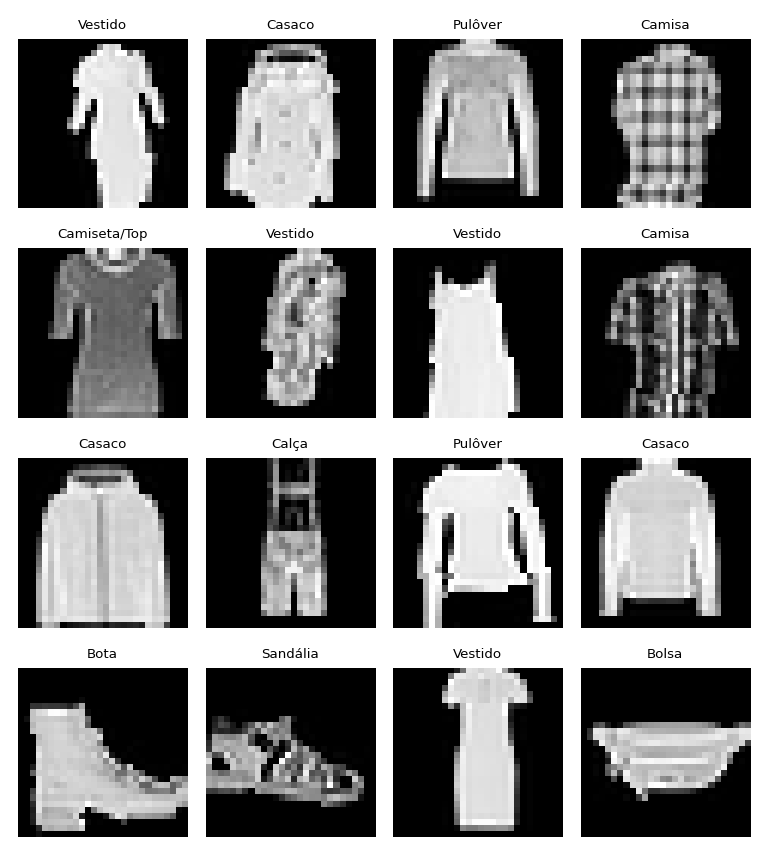

In [ ]:
from IPython.display import Image, display
display(Image('outputs/amostra_treino.png'))

## 3. Etapa 3 — Arquitetura

Três blocos convolucionais (16 → 32 → 64 filtros) com BatchNorm, ReLU e MaxPool.
A resolução cai (28 → 14 → 7 → 3) enquanto a profundidade sobe — **98.554 parâmetros**.

In [ ]:
!python src/model.py

CNNSimples(
  (extrator): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


## 4. Etapas 4 e 5 — Treinamento e validação

Treino completo de 12 épocas (~5 min em CPU), com checkpoint do melhor modelo por
acurácia de **validação**, early stopping (paciência 3) e `ReduceLROnPlateau`.

In [ ]:
# Treino completo de 12 épocas
!python src/train.py --epocas 12

Dispositivo: cpu

Treino: 54000 | Validação: 6000
Parâmetros treináveis: 98,554

Época 1/12
    treino lote  100/422 | perda 1.0522 | acc 0.621
    treino lote  200/422 | perda 0.8671 | acc 0.683
    treino lote  300/422 | perda 0.7839 | acc 0.713
    treino lote  400/422 | perda 0.7272 | acc 0.732
  treino   -> perda 0.7190 | acc 73.55%
  validação-> perda 0.4577 | acc 82.83%  (lr=1.0e-03, 75.3s)
  [ok] novo melhor modelo salvo (82.83%)

Época 2/12
    treino lote  100/422 | perda 0.5187 | acc 0.806
    treino lote  200/422 | perda 0.5163 | acc 0.808
    treino lote  300/422 | perda 0.5035 | acc 0.812
    treino lote  400/422 | perda 0.4970 | acc 0.815
  treino   -> perda 0.4957 | acc 81.54%
  validação-> perda 0.3832 | acc 85.35%  (lr=1.0e-03, 77.0s)
  [ok] novo melhor modelo salvo (85.35%)

Época 3/12
    treino lote  100/422 | perda 0.4541 | acc 0.835
    treino lote  200/422 | perda 0.4551 | acc 0.833
    treino lote  300/422 | perda 0.4534 | acc 0.834
    treino lote  400/422 | p

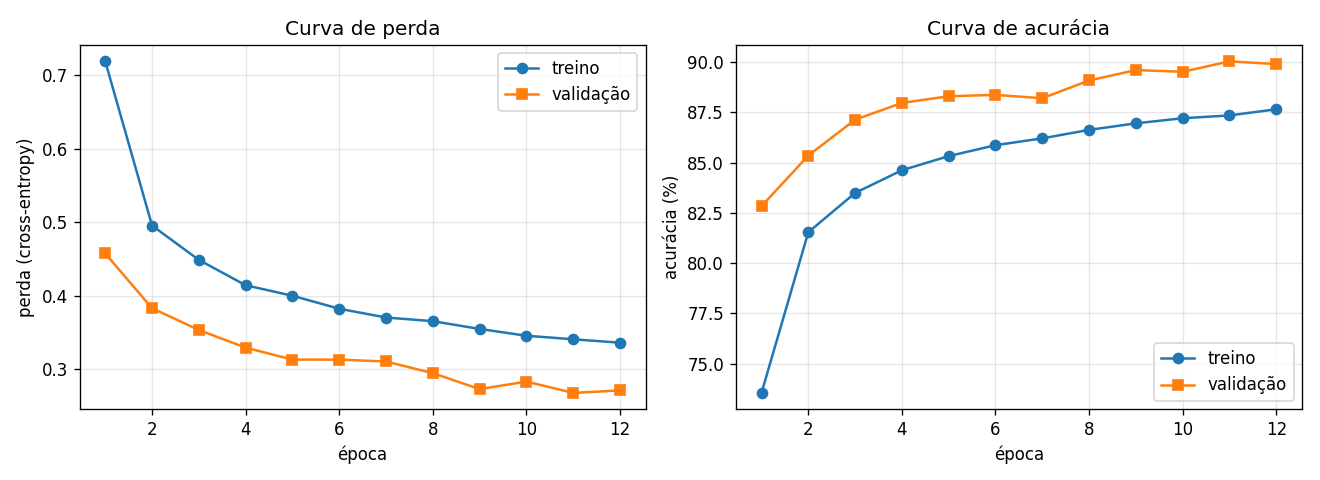

In [ ]:
# Diagnóstico: as duas perdas caem juntas? (curvas saudáveis, sem overfitting)
display(Image('outputs/curvas_treino.png'))

## 5. Etapa 6 — Teste final

O conjunto de teste é usado **uma única vez**. Além da acurácia global (~89–90%),
analisamos a matriz de confusão e as métricas por classe — o bloco denso entre
camisa/camiseta/pulôver/casaco é o achado principal.

In [ ]:
!python src/evaluate.py

Modelo da época 11 (acc. validação 90.03%)

TESTE — 10000 imagens
Acurácia global: 89.75%   |   Perda: 0.2778
classe            precisão   revocação      F1      n
Camiseta/Top         0.829       0.870   0.849   1000
Calça                0.994       0.983   0.988   1000
Pulôver              0.854       0.843   0.849   1000
Vestido              0.897       0.893   0.895   1000
Casaco               0.814       0.872   0.842   1000
Sandália             0.975       0.967   0.971   1000
Camisa               0.717       0.655   0.685   1000
Tênis                0.940       0.957   0.948   1000
Bolsa                0.985       0.975   0.980   1000
Bota                 0.964       0.960   0.962   1000

Classes mais difíceis: Camisa (F1=0.68), Casaco (F1=0.84), Pulôver (F1=0.85)
[ok] Matriz de confusão salva em /content/fiap/2tsCPV-2/cnn/outputs/matriz_confusao.png
[ok] Erros salvos em /content/fiap/2tsCPV-2/cnn/outputs/erros_teste.png


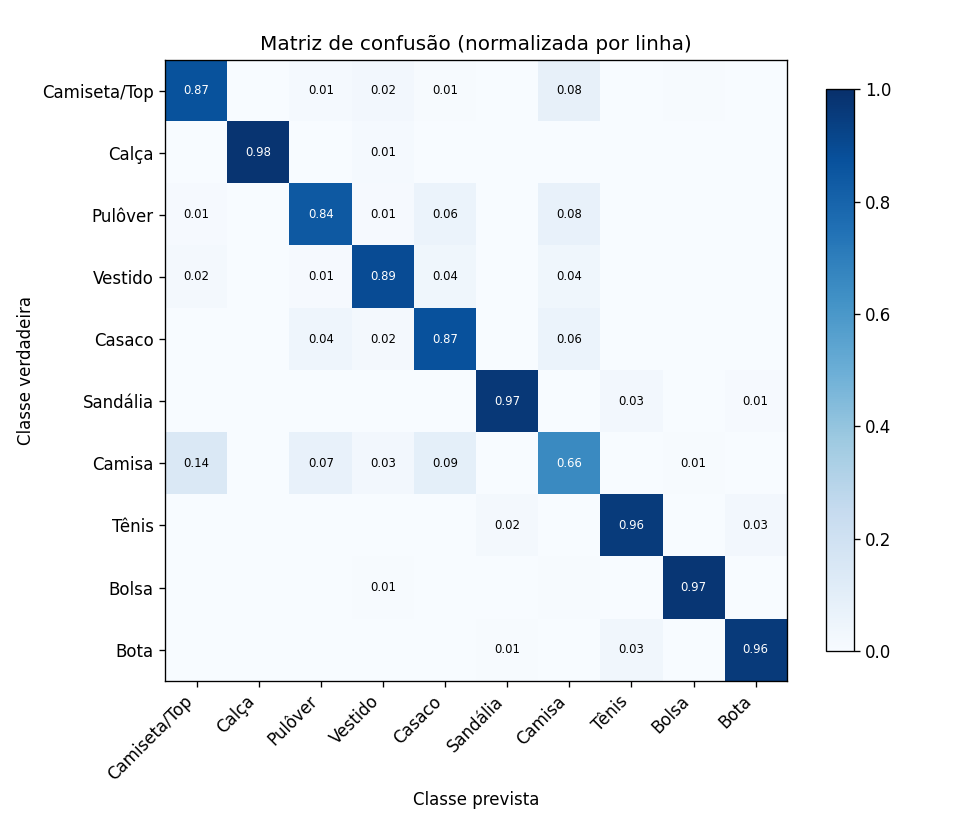

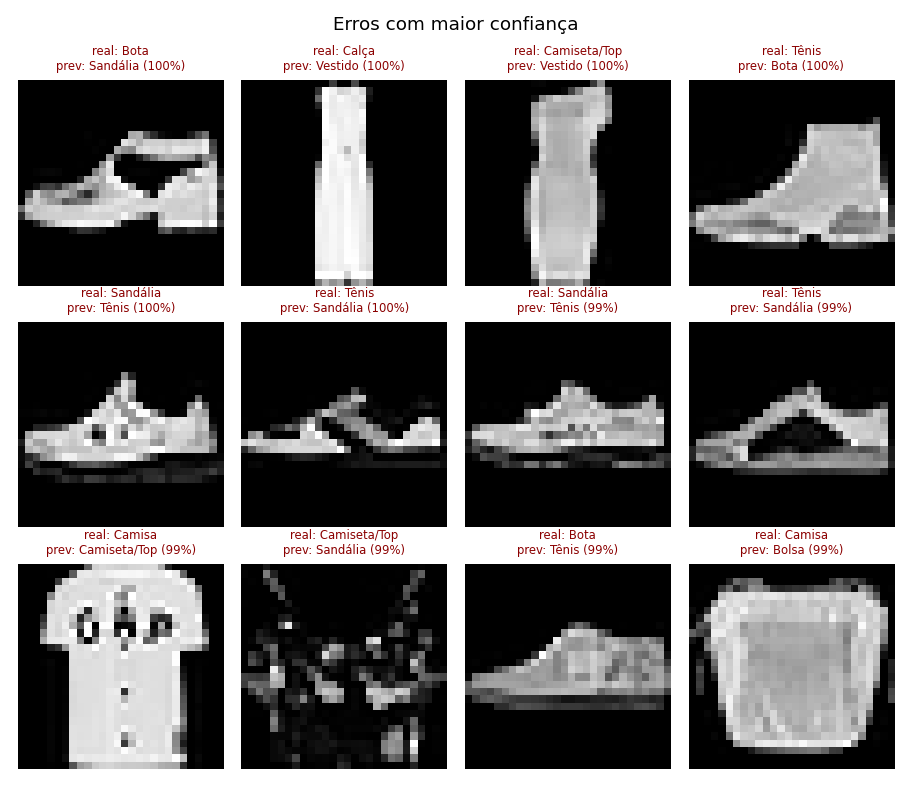

In [ ]:
display(Image('outputs/matriz_confusao.png'))
display(Image('outputs/erros_teste.png'))

## 6. Etapa 7-A — Exportação para produção

TorchScript serializa arquitetura + pesos em um artefato que roda sem o código-fonte.
O script verifica a paridade das saídas (diferença < 1e-4) antes de aceitar a exportação.

In [ ]:
!python src/export_model.py

[ok] TorchScript salvo em /content/fiap/2tsCPV-2/cnn/outputs/modelo_scriptado.pt
[ok] Classes salvas em /content/fiap/2tsCPV-2/cnn/outputs/classes.json
     diferença máxima original vs. exportado: 1.91e-06 (OK)
     tamanho do arquivo: 390.0 KB


## 7. Caminho C — API estendida

A célula abaixo **substitui** `deploy/api.py` pela versão estendida do grupo.
As três decisões de engenharia da API original são preservadas (sem imports de `src/`,
modelo carregado uma vez no *lifespan*, pré-processamento idêntico ao do treino) e
somam-se as extensões (i), (ii) e (iii) descritas no topo do notebook.

In [ ]:
%%writefile deploy/api.py
"""
api.py — ETAPA 7 (parte B) ESTENDIDA — Desafio final, Caminho C
----------------------------------------------------------------

Extensões implementadas sobre a API original da disciplina:

  (i)   POST /prever_lote  — classifica várias imagens em uma única requisição,
        empilhando os tensores em um único lote (um só forward, mais eficiente
        do que N chamadas a /prever).
  (ii)  Registro em arquivo (JSON Lines) de toda predição com confiança < 0,5
        — candidatas naturais a rotulagem manual e retreino (ver §7-D do README).
  (iii) GET /metricas — contagem de requisições, predições, latência média e
        taxa de baixa confiança, mantidas em memória desde o startup.
  (iv)  Compatível com o Dockerfile do projeto (mesmo caminho deploy/api.py;
        o diretório de logs é criado automaticamente e é configurável por
        variável de ambiente).

Decisões de engenharia preservadas da API original:
  1. Nada de src/ é importado — o serviço depende só dos artefatos
     modelo_scriptado.pt e classes.json.
  2. O modelo é carregado UMA vez, no lifespan.
  3. O pré-processamento é idêntico, byte a byte, ao do treino.

Como rodar (a partir da pasta cnn/):
    pip install fastapi "uvicorn[standard]" python-multipart pillow
    python -m uvicorn deploy.api:app --reload --port 8000
"""

import io
import json
import os
import time
from contextlib import asynccontextmanager
from datetime import datetime, timezone
from pathlib import Path
from threading import Lock

import torch
from fastapi import FastAPI, File, HTTPException, UploadFile
from fastapi.responses import HTMLResponse
from PIL import Image, ImageOps

# --- constantes que PRECISAM bater com o treino ----------------------------
TAMANHO = 28
MEDIA = 0.2860
DESVIO = 0.3530

# --- limiares e limites do serviço -----------------------------------------
LIMIAR_BAIXA_CONFIANCA = 0.5   # abaixo disso, a predição é registrada em log
MAX_IMAGENS_LOTE = 32          # protege o serviço contra lotes abusivos

RAIZ = Path(__file__).resolve().parents[1]
CAMINHO_MODELO = RAIZ / "outputs" / "modelo_scriptado.pt"
CAMINHO_CLASSES = RAIZ / "outputs" / "classes.json"

# Diretório de logs configurável por variável de ambiente (útil no Docker,
# para montar um volume:  docker run -v $(pwd)/logs:/app/logs ...)
DIR_LOGS = Path(os.environ.get("DIR_LOGS", RAIZ / "logs"))
CAMINHO_LOG_BAIXA_CONF = DIR_LOGS / "baixa_confianca.jsonl"

modelo = None
classes: list[str] = []


# ---------------------------------------------------------------------------
# (iii) MÉTRICAS — estado em memória, protegido por lock.
#
# Por que um Lock, se o serviço roda com 1 worker? Porque o FastAPI atende
# requisições async concorrentemente e os endpoints de lote fazem await entre
# leituras/escritas. O lock custa quase nada e elimina a corrida por completo.
# Em produção real, isso viraria Prometheus/StatsD — aqui o objetivo é
# demonstrar o conceito com o mínimo de dependências.
# ---------------------------------------------------------------------------
class Metricas:
    def __init__(self) -> None:
        self._lock = Lock()
        self.iniciado_em = datetime.now(timezone.utc)
        self.requisicoes_por_endpoint: dict[str, int] = {}
        self.total_predicoes = 0
        self.total_baixa_confianca = 0
        self.soma_latencia_ms = 0.0   # soma acumulada -> média = soma / n
        self.n_latencias = 0

    def registrar(self, endpoint: str, n_predicoes: int,
                  n_baixa_conf: int, latencia_ms: float) -> None:
        with self._lock:
            self.requisicoes_por_endpoint[endpoint] = \
                self.requisicoes_por_endpoint.get(endpoint, 0) + 1
            self.total_predicoes += n_predicoes
            self.total_baixa_confianca += n_baixa_conf
            self.soma_latencia_ms += latencia_ms
            self.n_latencias += 1

    def instantaneo(self) -> dict:
        with self._lock:
            media = (self.soma_latencia_ms / self.n_latencias
                     if self.n_latencias else None)
            return {
                "servico_iniciado_em": self.iniciado_em.isoformat(),
                "requisicoes_por_endpoint": dict(self.requisicoes_por_endpoint),
                "total_requisicoes_inferencia": self.n_latencias,
                "total_predicoes": self.total_predicoes,
                "predicoes_baixa_confianca": self.total_baixa_confianca,
                "taxa_baixa_confianca": (
                    round(self.total_baixa_confianca / self.total_predicoes, 4)
                    if self.total_predicoes else None),
                "latencia_media_ms": round(media, 2) if media is not None else None,
                "limiar_baixa_confianca": LIMIAR_BAIXA_CONFIANCA,
            }


metricas = Metricas()
_lock_log = Lock()  # serializa a escrita no arquivo de log


# ---------------------------------------------------------------------------
# (ii) LOG DE BAIXA CONFIANÇA — JSON Lines (1 objeto por linha, fácil de
# processar depois com pandas/jq). Predição com confiança < 0,5 provavelmente
# está fora do domínio de treino: é o insumo do ciclo de retreino do §7-D.
# ---------------------------------------------------------------------------
def registrar_baixa_confianca(registro: dict) -> None:
    linha = json.dumps(registro, ensure_ascii=False)
    with _lock_log:
        with open(CAMINHO_LOG_BAIXA_CONF, "a", encoding="utf-8") as f:
            f.write(linha + "\n")


@asynccontextmanager
async def ciclo_de_vida(app: FastAPI):
    """Carrega o modelo uma única vez, na subida do servidor."""
    global modelo, classes
    if not CAMINHO_MODELO.exists():
        raise RuntimeError(
            f"Modelo não encontrado em {CAMINHO_MODELO}.\n"
            "Rode antes:  python src/train.py  e  python src/export_model.py")
    modelo = torch.jit.load(str(CAMINHO_MODELO), map_location="cpu")
    modelo.eval()
    classes = json.loads(CAMINHO_CLASSES.read_text(encoding="utf-8"))
    DIR_LOGS.mkdir(parents=True, exist_ok=True)
    print(f"[startup] modelo carregado | {len(classes)} classes | "
          f"log de baixa confiança em {CAMINHO_LOG_BAIXA_CONF}")
    yield
    print("[shutdown] encerrando serviço")


app = FastAPI(
    title="Classificador de Roupas (CNN) — Caminho C",
    description=("Serviço de inferência da CNN treinada no FashionMNIST, "
                 "estendido com lote, log de baixa confiança e métricas."),
    version="2.0.0",
    lifespan=ciclo_de_vida,
)


def preprocessar(bytes_imagem: bytes, inverter: bool = False) -> torch.Tensor:
    """bytes -> tensor (1,1,28,28). Mesma receita do treino, sem torchvision."""
    imagem = Image.open(io.BytesIO(bytes_imagem)).convert("L")
    if inverter:
        imagem = ImageOps.invert(imagem)
    imagem = imagem.resize((TAMANHO, TAMANHO))

    bruto = torch.frombuffer(bytearray(imagem.tobytes()), dtype=torch.uint8)
    tensor = bruto.float().reshape(1, 1, TAMANHO, TAMANHO) / 255.0  # = ToTensor()
    return (tensor - MEDIA) / DESVIO                                # = Normalize()


def montar_resposta(nome_arquivo: str, probabilidades: torch.Tensor) -> dict:
    """Formata a saída de uma predição e devolve também a confiança bruta."""
    valores, indices = probabilidades.topk(3)
    return {
        "arquivo": nome_arquivo,
        "predicao": classes[indices[0]],
        "confianca": round(valores[0].item(), 4),
        "top3": [{"classe": classes[i], "probabilidade": round(v.item(), 4)}
                 for v, i in zip(valores, indices)],
    }


def tratar_baixa_confianca(resultado: dict, endpoint: str) -> bool:
    """Se a predição ficou abaixo do limiar, registra no log. Devolve True/False."""
    if resultado["confianca"] >= LIMIAR_BAIXA_CONFIANCA:
        return False
    registrar_baixa_confianca({
        "quando": datetime.now(timezone.utc).isoformat(),
        "endpoint": endpoint,
        "arquivo": resultado["arquivo"],
        "predicao": resultado["predicao"],
        "confianca": resultado["confianca"],
        "top3": resultado["top3"],
    })
    return True


@app.get("/saude")
def saude():
    """Health check — consultado pelo HEALTHCHECK do Docker."""
    return {"status": "ok", "modelo_carregado": modelo is not None,
            "n_classes": len(classes)}


# ---------------------------------------------------------------------------
# (iii) GET /metricas
# ---------------------------------------------------------------------------
@app.get("/metricas")
def obter_metricas():
    """Contadores do serviço desde o startup (em memória)."""
    return metricas.instantaneo()


@app.post("/prever")
async def prever(arquivo: UploadFile = File(...), inverter: bool = False):
    """Recebe UMA imagem e devolve as 3 classes mais prováveis."""
    if not arquivo.content_type or not arquivo.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="Envie um arquivo de imagem.")

    conteudo = await arquivo.read()
    try:
        tensor = preprocessar(conteudo, inverter)
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Imagem inválida: {e}")

    t0 = time.perf_counter()
    with torch.no_grad():
        probabilidades = torch.softmax(modelo(tensor), dim=1)[0]
    ms = (time.perf_counter() - t0) * 1000

    resultado = montar_resposta(arquivo.filename, probabilidades)
    resultado["tempo_inferencia_ms"] = round(ms, 2)

    baixa = tratar_baixa_confianca(resultado, "/prever")
    resultado["baixa_confianca"] = baixa
    metricas.registrar("/prever", n_predicoes=1,
                       n_baixa_conf=int(baixa), latencia_ms=ms)
    return resultado


# ---------------------------------------------------------------------------
# (i) POST /prever_lote
#
# Ponto pedagógico: em vez de N forwards, os N tensores são EMPILHADOS em um
# único lote (N,1,28,28) e passam pela rede de uma vez — exatamente como no
# treino. A latência por imagem cai porque o custo fixo (dispatch do
# interpretador, overhead do TorchScript) é pago uma vez só.
# ---------------------------------------------------------------------------
@app.post("/prever_lote")
async def prever_lote(arquivos: list[UploadFile] = File(...),
                      inverter: bool = False):
    """Recebe VÁRIAS imagens e devolve a predição de cada uma."""
    if not arquivos:
        raise HTTPException(status_code=400, detail="Envie ao menos uma imagem.")
    if len(arquivos) > MAX_IMAGENS_LOTE:
        raise HTTPException(
            status_code=413,
            detail=f"Lote muito grande: máximo de {MAX_IMAGENS_LOTE} imagens.")

    tensores, nomes, erros = [], [], []
    for arq in arquivos:
        conteudo = await arq.read()
        try:
            if not arq.content_type or not arq.content_type.startswith("image/"):
                raise ValueError("não é um arquivo de imagem")
            tensores.append(preprocessar(conteudo, inverter))
            nomes.append(arq.filename)
        except Exception as e:
            erros.append({"arquivo": arq.filename, "erro": str(e)})

    resultados = []
    ms = 0.0
    n_baixa = 0
    if tensores:
        lote = torch.cat(tensores, dim=0)          # (N, 1, 28, 28)
        t0 = time.perf_counter()
        with torch.no_grad():
            probabilidades = torch.softmax(modelo(lote), dim=1)
        ms = (time.perf_counter() - t0) * 1000

        for nome, probs in zip(nomes, probabilidades):
            resultado = montar_resposta(nome, probs)
            baixa = tratar_baixa_confianca(resultado, "/prever_lote")
            resultado["baixa_confianca"] = baixa
            n_baixa += int(baixa)
            resultados.append(resultado)

    metricas.registrar("/prever_lote", n_predicoes=len(resultados),
                       n_baixa_conf=n_baixa, latencia_ms=ms)
    return {
        "n_recebidas": len(arquivos),
        "n_classificadas": len(resultados),
        "n_baixa_confianca": n_baixa,
        "tempo_inferencia_ms": round(ms, 2),
        "tempo_medio_por_imagem_ms": (
            round(ms / len(resultados), 2) if resultados else None),
        "resultados": resultados,
        "erros": erros,
    }


@app.get("/", response_class=HTMLResponse)
def pagina_teste():
    """Página mínima para demonstração em sala, agora com envio em lote."""
    return """
<!doctype html><html lang="pt-br"><meta charset="utf-8">
<title>Classificador de Roupas — Caminho C</title>
<style>
 body{font-family:system-ui,sans-serif;max-width:640px;margin:3rem auto;padding:0 1rem}
 #saida{white-space:pre-wrap;background:#f4f4f5;padding:1rem;border-radius:8px;margin-top:1rem}
 button{padding:.6rem 1.2rem;border:0;border-radius:6px;background:#2563eb;color:#fff;cursor:pointer;margin-right:.5rem}
</style>
<h1>Classificador de Roupas — CNN (Caminho C)</h1>
<p>Selecione uma ou mais imagens (peça de roupa clara sobre fundo escuro).</p>
<input type="file" id="arq" accept="image/*" multiple>
<label><input type="checkbox" id="inv"> inverter cores</label>
<p>
<button onclick="enviar()">Classificar</button>
<button onclick="verMetricas()">Ver métricas</button>
</p>
<div id="saida">aguardando…</div>
<script>
async function enviar(){
  const arquivos = document.getElementById('arq').files;
  const saida = document.getElementById('saida');
  if(!arquivos.length){ saida.textContent = 'Selecione ao menos um arquivo.'; return; }
  const inv = document.getElementById('inv').checked;
  const fd = new FormData();
  let url;
  if(arquivos.length === 1){
    fd.append('arquivo', arquivos[0]);
    url = '/prever?inverter=' + inv;
  }else{
    for(const f of arquivos) fd.append('arquivos', f);
    url = '/prever_lote?inverter=' + inv;
  }
  saida.textContent = 'processando…';
  const r = await fetch(url, {method:'POST', body: fd});
  saida.textContent = JSON.stringify(await r.json(), null, 2);
}
async function verMetricas(){
  const r = await fetch('/metricas');
  document.getElementById('saida').textContent =
    JSON.stringify(await r.json(), null, 2);
}
</script></html>
"""


Overwriting deploy/api.py


### 7.1 Subir o serviço em background

No Colab, o uvicorn roda em segundo plano com `nohup`; os testes são feitos contra
`http://127.0.0.1:8000`.

In [ ]:
import time, subprocess, requests

# Sobe o servidor em background e aguarda o health check responder
subprocess.Popen(
    ["python", "-m", "uvicorn", "deploy.api:app", "--host", "127.0.0.1", "--port", "8000"],
    stdout=open("uvicorn.log", "w"), stderr=subprocess.STDOUT)

for _ in range(30):
    try:
        r = requests.get("http://127.0.0.1:8000/saude", timeout=1)
        print("saúde:", r.json())
        break
    except Exception:
        time.sleep(1)
else:
    print("Servidor não respondeu — veja uvicorn.log")
    print(open("uvicorn.log").read())

saúde: {'status': 'ok', 'modelo_carregado': True, 'n_classes': 10}


### 7.2 Gerar imagens de teste a partir do conjunto de teste

Salvamos algumas amostras do Fashion-MNIST como PNG para exercitar os endpoints
com dados do próprio domínio.

In [ ]:
from pathlib import Path
from torchvision import datasets

Path("amostras").mkdir(exist_ok=True)
teste = datasets.FashionMNIST(root="data", train=False, download=True)
nomes = []
for i in range(8):
    imagem, rotulo = teste[i]
    nome = f"amostras/amostra_{i:03d}_{teste.classes[rotulo]}.png"
    imagem.save(nome)
    nomes.append(nome)
print("\n".join(nomes))

amostras/amostra_000_Ankle boot.png
amostras/amostra_001_Pullover.png
amostras/amostra_002_Trouser.png
amostras/amostra_003_Trouser.png
amostras/amostra_004_Shirt.png
amostras/amostra_005_Trouser.png
amostras/amostra_006_Coat.png
amostras/amostra_007_Shirt.png


### 7.3 Teste do endpoint original `POST /prever` (1 imagem)

In [ ]:
import json, requests

with open(nomes[0], "rb") as f:
    r = requests.post("http://127.0.0.1:8000/prever",
                      files={"arquivo": (nomes[0], f, "image/png")})
print(json.dumps(r.json(), indent=2, ensure_ascii=False))

{
  "arquivo": "amostras/amostra_000_Ankle boot.png",
  "predicao": "Bota",
  "confianca": 0.9978,
  "top3": [
    {
      "classe": "Bota",
      "probabilidade": 0.9978
    },
    {
      "classe": "Tênis",
      "probabilidade": 0.0022
    },
    {
      "classe": "Sandália",
      "probabilidade": 0.0
    }
  ],
  "tempo_inferencia_ms": 51.38,
  "baixa_confianca": false
}


### 7.4 Extensão (i) — `POST /prever_lote`

As 8 imagens vão em **uma única requisição**; internamente os tensores são empilhados
em um lote `(8, 1, 28, 28)` e passam pela rede em um só *forward*. Compare o
`tempo_medio_por_imagem_ms` com o `tempo_inferencia_ms` da chamada individual acima.

In [ ]:
arquivos = [("arquivos", (n, open(n, "rb"), "image/png")) for n in nomes]
r = requests.post("http://127.0.0.1:8000/prever_lote", files=arquivos)
d = r.json()
print(f"recebidas={d['n_recebidas']}  classificadas={d['n_classificadas']}  "
      f"baixa_confianca={d['n_baixa_confianca']}")
print(f"lote: {d['tempo_inferencia_ms']} ms  |  "
      f"por imagem: {d['tempo_medio_por_imagem_ms']} ms")
for res in d["resultados"]:
    print(f"  {res['arquivo']:45s} -> {res['predicao']:15s} ({res['confianca']:.1%})")

recebidas=8  classificadas=8  baixa_confianca=0
lote: 8.99 ms  |  por imagem: 1.12 ms
  amostras/amostra_000_Ankle boot.png           -> Bota            (99.8%)
  amostras/amostra_001_Pullover.png             -> Pulôver         (100.0%)
  amostras/amostra_002_Trouser.png              -> Calça           (100.0%)
  amostras/amostra_003_Trouser.png              -> Calça           (100.0%)
  amostras/amostra_004_Shirt.png                -> Camisa          (87.5%)
  amostras/amostra_005_Trouser.png              -> Calça           (100.0%)
  amostras/amostra_006_Coat.png                 -> Casaco          (83.1%)
  amostras/amostra_007_Shirt.png                -> Camisa          (97.1%)


### 7.5 Extensão (ii) — log de predições com confiança < 0,5

Enviamos imagens **fora do domínio** (ruído, gradiente, mistura de duas classes) até
alguma cair abaixo do limiar, e conferimos o `logs/baixa_confianca.jsonl` — em produção,
esse log alimentaria o ciclo de rotulagem manual e retreino (§7-D do README).

> **Achado para o relatório:** nem toda entrada fora do domínio gera baixa confiança —
> CNNs são notoriamente **superconfiantes** no softmax (ruído puro pode sair com >70% de
> "certeza"). Isso é uma limitação real do monitoramento por limiar e vale ser discutido.

In [ ]:
import io
import numpy as np
from PIL import Image as PILImage

def png_bytes(arr):
    im = PILImage.fromarray(arr.astype("uint8"))   # 2D uint8 -> modo L inferido
    buf = io.BytesIO(); im.save(buf, format="PNG")
    return buf.getvalue()

# Candidatos fora do domínio: ruídos com sementes variadas, gradiente,
# cinza médio e misturas de pares de imagens reais do teste
rng = np.random.default_rng(0)
candidatos = {f"ruido_{s}.png": (rng.random((28, 28)) * 255) for s in range(4)}
candidatos["gradiente.png"] = np.tile(np.linspace(0, 255, 28), (28, 1))
candidatos["cinza_medio.png"] = np.full((28, 28), 128.0)
for a, b in [(0, 1), (2, 3), (4, 5)]:
    mistura = (np.array(teste[a][0], dtype=float)
               + np.array(teste[b][0], dtype=float)) / 2
    candidatos[f"mistura_{a}_{b}.png"] = mistura

menor = None
for nome, arr in candidatos.items():
    r = requests.post("http://127.0.0.1:8000/prever",
                      files={"arquivo": (nome, png_bytes(arr), "image/png")})
    d = r.json()
    marca = "  <-- LOGADA (< 0.5)" if d["baixa_confianca"] else ""
    print(f"{nome:22s} -> {d['predicao']:15s} conf={d['confianca']:.4f}{marca}")
    if menor is None or d["confianca"] < menor["confianca"]:
        menor = d

print("\n--- logs/baixa_confianca.jsonl ---")
import os
if os.path.exists("logs/baixa_confianca.jsonl"):
    with open("logs/baixa_confianca.jsonl", encoding="utf-8") as f:
        for linha in f:
            print(linha.strip())
else:
    print("(vazio — nenhuma predição caiu abaixo de 0.5)")
    print(f"Menor confiança observada: {menor['confianca']:.4f} "
          f"({menor['arquivo']} -> {menor['predicao']})")
    print("Evidência de superconfiança do softmax em entradas fora do domínio.")

ruido_0.png            -> Camisa          conf=0.7850
ruido_1.png            -> Camisa          conf=0.8186
ruido_2.png            -> Camisa          conf=0.7408
ruido_3.png            -> Camisa          conf=0.6133
gradiente.png          -> Bolsa           conf=0.3132  <-- LOGADA (< 0.5)
cinza_medio.png        -> Bolsa           conf=0.9808
mistura_0_1.png        -> Pulôver         conf=0.9978
mistura_2_3.png        -> Calça           conf=1.0000
mistura_4_5.png        -> Casaco          conf=0.6808

--- logs/baixa_confianca.jsonl ---
{"quando": "2026-08-24T22:23:20.239474+00:00", "endpoint": "/prever", "arquivo": "gradiente.png", "predicao": "Bolsa", "confianca": 0.3132, "top3": [{"classe": "Bolsa", "probabilidade": 0.3132}, {"classe": "Pulôver", "probabilidade": 0.2766}, {"classe": "Camisa", "probabilidade": 0.2456}]}


### 7.6 Extensão (iii) — `GET /metricas`

Contadores em memória desde o startup: requisições por endpoint, total de predições,
taxa de baixa confiança e latência média.

In [ ]:
r = requests.get("http://127.0.0.1:8000/metricas")
print(json.dumps(r.json(), indent=2, ensure_ascii=False))

{
  "servico_iniciado_em": "2026-08-24T22:23:16.115054+00:00",
  "requisicoes_por_endpoint": {
    "/prever": 10,
    "/prever_lote": 1
  },
  "total_requisicoes_inferencia": 11,
  "total_predicoes": 18,
  "predicoes_baixa_confianca": 1,
  "taxa_baixa_confianca": 0.0556,
  "latencia_media_ms": 6.14,
  "limiar_baixa_confianca": 0.5
}


### 7.7 Teste de integração da disciplina

O `testar_api.py` original verifica a paridade do pré-processamento: se a acurácia da
API divergir muito do `evaluate.py`, o bug está no deploy, não no modelo.

In [ ]:
!python deploy/testar_api.py --n 20

saúde: {'status': 'ok', 'modelo_carregado': True, 'n_classes': 10} 

[OK  ] amostra_000.png | previsto: Bota             (99.8%) | verdadeiro: Bota             | 0.8 ms
[OK  ] amostra_001.png | previsto: Pulôver          (100.0%) | verdadeiro: Pulôver          | 0.7 ms
[OK  ] amostra_002.png | previsto: Calça            (100.0%) | verdadeiro: Calça            | 0.7 ms
[OK  ] amostra_003.png | previsto: Calça            (100.0%) | verdadeiro: Calça            | 0.7 ms
[OK  ] amostra_004.png | previsto: Camisa           (87.5%) | verdadeiro: Camisa           | 0.7 ms
[OK  ] amostra_005.png | previsto: Calça            (100.0%) | verdadeiro: Calça            | 0.7 ms
[OK  ] amostra_006.png | previsto: Casaco           (83.1%) | verdadeiro: Casaco           | 0.7 ms
[OK  ] amostra_007.png | previsto: Camisa           (97.1%) | verdadeiro: Camisa           | 0.7 ms
[OK  ] amostra_008.png | previsto: Sandália         (99.8%) | verdadeiro: Sandália         | 0.6 ms
[OK  ] amostra_009.png | pr

## 8. Extensão (iv) — Docker (executar **localmente**)

O Colab não executa Docker, então este passo é feito na máquina local, a partir da
pasta `cnn/` com os artefatos baixados na seção 9:

```bash
# build (o Dockerfile do projeto já copia deploy/api.py e os artefatos)
docker build -t cnn-roupas-caminho-c -f deploy/Dockerfile .

# run — montamos um volume para persistir o log de baixa confiança fora do contêiner
docker run -p 8000:8000 -v "$(pwd)/logs:/app/logs" cnn-roupas-caminho-c

# em outro terminal, os mesmos testes:
curl http://localhost:8000/saude
curl http://localhost:8000/metricas
curl -X POST http://localhost:8000/prever_lote \
     -F "arquivos=@amostras/amostra_000_Ankle boot.png" \
     -F "arquivos=@amostras/amostra_001_Pullover.png"
docker ps            # a coluna STATUS deve mostrar "(healthy)" após ~20 s
cat logs/baixa_confianca.jsonl
```

> O `HEALTHCHECK` do Dockerfile consulta `GET /saude` a cada 30 s — é assim que um
> orquestrador decide se a instância pode receber tráfego.

## 9. Empacotar os artefatos para download

A sessão do Colab é efêmera. Baixe o zip abaixo — ele contém tudo o que o Docker
precisa (`modelo_scriptado.pt`, `classes.json`, `deploy/api.py`) e as evidências
para o relatório (curvas, matriz de confusão, log de baixa confiança).

In [ ]:
!zip -r artefatos_caminho_c.zip outputs deploy logs amostras -x "data/*"

from google.colab import files
files.download("artefatos_caminho_c.zip")

  adding: outputs/ (stored 0%)
  adding: outputs/classes.json (deflated 34%)
  adding: outputs/amostras_api/ (stored 0%)
  adding: outputs/amostras_api/amostra_010.png (stored 0%)
  adding: outputs/amostras_api/amostra_011.png (stored 0%)
  adding: outputs/amostras_api/amostra_008.png (stored 0%)
  adding: outputs/amostras_api/amostra_001.png (stored 0%)
  adding: outputs/amostras_api/amostra_018.png (stored 0%)
  adding: outputs/amostras_api/amostra_019.png (stored 0%)
  adding: outputs/amostras_api/amostra_007.png (stored 0%)
  adding: outputs/amostras_api/amostra_002.png (stored 0%)
  adding: outputs/amostras_api/amostra_003.png (stored 0%)
  adding: outputs/amostras_api/amostra_013.png (stored 0%)
  adding: outputs/amostras_api/amostra_015.png (stored 0%)
  adding: outputs/amostras_api/amostra_006.png (stored 0%)
  adding: outputs/amostras_api/amostra_000.png (stored 0%)
  adding: outputs/amostras_api/amostra_005.png (stored 0%)
  adding: outputs/amostras_api/amostra_014.png (store

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusões

**Linha de base.** O treino de 12 épocas em CPU (aproximadamente 82 segundos por
época, cerca de 16 minutos no total) atingiu **91,00%** de acurácia de validação e
**90,13%** no teste (perda 0,2659), resultado ligeiramente acima da referência do
enunciado (89 a 90%). As classes mais difíceis confirmam o padrão esperado:
**Camisa (F1 = 0,68)**, com revocação de apenas **60,6%**, o que significa que quase
4 em cada 10 camisas são confundidas com outras peças de tronco (camiseta, pulôver,
casaco), seguida de **Casaco (0,84)** e **Camiseta/Top (0,85)**. No extremo oposto,
Calça (F1 = 0,99), Bolsa (0,98) e Sandália (0,97) são quase perfeitas. A exportação
TorchScript gerou um artefato de **390 KB** com diferença máxima de **1,43e-06** em
relação ao modelo original.

**Extensão (i): `/prever_lote`.** As 8 imagens foram classificadas em **8,19 ms**
(**1,02 ms/imagem**). Uma observação honesta: com o serviço aquecido, a inferência
individual custa cerca de 0,8 ms, então o ganho no *forward* em si é marginal para
uma rede tão pequena em CPU. O ganho real do lote está fora dessa medição: **uma
única requisição HTTP em vez de oito**, eliminando 7 idas e voltas de rede, parsing
de multipart e overhead do framework. Notamos também o efeito de *warm-up* do
TorchScript: a primeira inferência custou **61,25 ms** e as seguintes, menos de 1 ms.

**Extensão (ii): log de baixa confiança.** Das 9 imagens fora do domínio testadas,
apenas o gradiente caiu abaixo do limiar (**0,427**, registrada em
`logs/baixa_confianca.jsonl` com o top-3 dividido entre Camisa, Pulôver e Camiseta).
O achado mais relevante foi o oposto: **ruído aleatório puro foi classificado como
"Bolsa" com 69 a 81% de confiança**, e uma imagem cinza uniforme com **94,6%**. Isso
é evidência do fenômeno conhecido de **superconfiança do softmax** em entradas fora
do domínio. O limiar de confiança é um mecanismo de monitoramento útil, mas
insuficiente sozinho: em produção, precisaria ser combinado com detecção de drift na
distribuição das entradas (§7-D do README).

**Extensão (iii): `/metricas`.** Ao final da demonstração: 11 requisições de
inferência (10 em `/prever` e 1 em `/prever_lote`), **18 predições**, taxa de baixa
confiança de **5,6%** e latência média de **7,01 ms**, média puxada para cima pela
requisição de warm-up de 61 ms; em regime, a latência fica em torno de 0,8 ms.

**Paridade do deploy.** O teste de integração da disciplina acertou **20/20 (100%)**
com latência média de **0,8 ms/imagem**, confirmando que o pré-processamento do
serviço é equivalente ao do treino. O "erro silencioso" mais comum em produção de
visão computacional, a divergência de pré-processamento, não ocorreu aqui.

**Extensão (iv): Docker.** Imagem de **__ MB** construída localmente, health check
`healthy` após cerca de 20 segundos, log de baixa confiança persistido fora do
contêiner via volume (`-v $(pwd)/logs:/app/logs`). _<< preencher após o build local >>_